In [ ]:
import pandas as pd
import numpy as np
import sklearn.ensemble
import sklearn.preprocessing
import sklearn.metrics
from sklearn.model_selection import train_test_split

# 1 Load and explore the dataset

In [ ]:
# load csv
df0 = pd.read_csv('titanic.csv')
df0.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
# let's print the number of samples
print(df0.shape)

(891, 12)


We can easily identify the types of the variables
- int / float it is a number
- object is cathegorical data
- bool boolean

In [ ]:
df0.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df = df0.drop(['Name', 'Ticket', 'Cabin'], axis=1).copy()
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,NaN,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [ ]:
# convert all types
df = df.convert_dtypes()
print(df.dtypes)

PassengerId             Int64
Survived                Int64
Pclass                  Int64
Sex            string[python]
Age                   Float64
SibSp                   Int64
Parch                   Int64
Fare                  Float64
Embarked       string[python]
dtype: object


In [ ]:
#a = df['Embarked'].unique()
#a

Let's identify how many missing values there are

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


We want to convert this number in percentage

In [ ]:
df.isna().sum() / len(df) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Fare,0.000000
Embarked,0.224467


# 2 Clean the dataset

There are NaN values!

We have three options:
1. drop variables with missing values
2. drop samples with missing values
3. replace missing value with synthetic value

## Case 1 - Drop variables with missing values

In [ ]:
df.dropna(axis=0)
# if we want to drop only if a specific column has nan:
# df.dropna(subset=['liver_big'],axis=0)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.25,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.925,S
3,4,1,1,female,35.0,1,0,53.1,S
4,5,0,3,male,35.0,0,0,8.05,S
...,...,...,...,...,...,...,...,...,...
885,886,0,3,female,39.0,0,5,29.125,Q
886,887,0,2,male,27.0,0,0,13.0,S
887,888,1,1,female,19.0,0,0,30.0,S
889,890,1,1,male,26.0,0,0,30.0,C


## Case 2 - Drop samples with missing values

In [ ]:
# case 2
df.dropna(axis=1)

,PassengerId,Survived,Pclass,Sex,SibSp,Parch,Fare
0,1,0,3,male,1,0,7.25
1,2,1,1,female,1,0,71.2833
2,3,1,3,female,0,0,7.925
3,4,1,1,female,1,0,53.1
4,5,0,3,male,0,0,8.05
...,...,...,...,...,...,...,...
886,887,0,2,male,0,0,13.0
887,888,1,1,female,0,0,30.0
888,889,0,3,female,1,2,23.45
889,890,1,1,male,0,0,30.0


In [ ]:
# We can also delete variables only if the amount of nan is above a threshold
df.dropna(thresh=0.8*len(df),axis=1)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.25,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.925,S
3,4,1,1,female,35.0,1,0,53.1,S
4,5,0,3,male,35.0,0,0,8.05,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0,S
887,888,1,1,female,19.0,0,0,30.0,S
888,889,0,3,female,<NA>,1,2,23.45,S
889,890,1,1,male,26.0,0,0,30.0,C


## Case 3 (preferred) - we want to insert generated values

- In case of numerical values, we can replace the missing value with the average value of the column
- In case of cathegorical values we can replace the missing value with the most frequent value of the column

.fillna(value) replaces all the NaNs with values passed as argument


#### Boolean columns

In [ ]:
# get columns containing booleans
boolean_cols = df.select_dtypes(include=bool).columns.tolist()
boolean_cols

[]

In [ ]:
# # get most frequent values
# most_frequent_values = df[boolean_cols].mode().loc[0]

# # replace missing content with mode
# df[boolean_cols] = df[boolean_cols].fillna(most_frequent_values)

# df

#### Integer values

In [ ]:
# get columns containing numbers
numeric = df.select_dtypes(include=int)
integer_columns = numeric.columns
# print them
integer_columns

Index(['PassengerId', 'Survived', 'Pclass', 'SibSp', 'Parch'], dtype='object')

In [ ]:
# replace these columns with their median
median_of_integer_cols = df[integer_columns].median()
df[integer_columns] = df[integer_columns].fillna(median_of_integer_cols)

#### Float columns

In [ ]:
# get columns containing numbers
# numeric = df.select_dtypes(include=np.number)
numeric = df.select_dtypes(include=float)
numeric_columns = numeric.columns
# print them
numeric_columns

Index(['Age', 'Fare'], dtype='object')

In [ ]:
# replace these columns with their median
# median_of_numeric_cols = df[numeric_columns].median()
# df[numeric_columns] = df[numeric_columns].fillna(median_of_numeric_cols)

# convert all floats64 to floats
df[numeric_columns] = df[numeric_columns].astype(float)

# interpolate
df[numeric_columns] = df[numeric_columns].interpolate(method ='linear')

#### Categorical columns

In [ ]:
# get categorical columns
categorical_columns = df.select_dtypes(include='string').columns.tolist()
print(categorical_columns)

['Sex', 'Embarked']


In [ ]:
# let's get the most frequent values
most_frequent_values = df[categorical_columns].mode()
most_frequent_values

,Sex,Embarked
0,male,S


In [ ]:
df[categorical_columns] = df[categorical_columns].fillna(most_frequent_values.iloc[0])

df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,22.5,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [ ]:
# final check
df.isnull().values.any()

np.False_

# 2 Encode the features

We need to encode the target variable through labeling

In [ ]:
# df = pd.concat([df,pd.get_dummies(df['Embarked'],prefix='Embarked')]
# axis=1)
# df = df.drop('Embarked', axis=1)
# df

In [ ]:
# # initialize label encoder
# le = sklearn.preprocessing.LabelEncoder()

# # encode target class
# df['class'] = le.fit_transform(df['class'])

We need to encode cathegorical features through one-hot encoding

In [ ]:
# get columns containing cathegorical features
categorical_features = df.select_dtypes(include='string').columns.tolist()
categorical_features

['Sex', 'Embarked']

In [ ]:
# one-hot encode these features
df = pd.get_dummies(df, prefix=categorical_features)
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,2,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,False,True,False,False,True
887,888,1,1,19.0,0,0,30.0000,True,False,False,False,True
888,889,0,3,22.5,1,2,23.4500,True,False,False,False,True
889,890,1,1,26.0,0,0,30.0000,False,True,True,False,False


# 3 Let's find outlayers

### Isolation forests

In [ ]:
# initialize forest
isoforest = sklearn.ensemble.IsolationForest(n_estimators=1000, contamination=0.01, random_state=0)
# for each sample, get anomaly score
res = isoforest.fit_predict(df.to_numpy())
res

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [ ]:
df_iso = df.drop(df[res==-1].index).copy()
df_iso.shape

(882, 12)

### PCA

In [ ]:
# init pca object
pca = sklearn.decomposition.PCA(n_components=0.9999)
# apply pca
X_pca = pca.fit_transform(df)
# invert pca
X_ori = pca.inverse_transform(X_pca)
# define anomaly score as the sum of the absolute distances
anomaly_score = np.abs(df.to_numpy() - X_ori).sum(1)
# get last quantile
threshold = np.quantile(anomaly_score, 0.99)
# get ids of anomalous values
anomalous_ids = np.argwhere(anomaly_score > threshold).squeeze()

In [ ]:
df.iloc[anomalous_ids]

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
159,160,0,3,39.333333,8,2,69.5500,False,True,False,False,True
180,181,0,3,27.000000,8,2,69.5500,True,False,False,False,True
201,202,0,3,31.000000,8,2,69.5500,False,True,False,False,True
324,325,0,3,29.000000,8,2,69.5500,False,True,False,False,True
679,680,1,1,36.000000,0,1,512.3292,False,True,True,False,False
737,738,1,1,35.000000,0,0,512.3292,False,True,True,False,False
792,793,0,3,19.000000,8,2,69.5500,True,False,False,False,True
846,847,0,3,38.500000,8,2,69.5500,False,True,False,False,True
863,864,0,3,36.000000,8,2,69.5500,True,False,False,False,True


In [ ]:
df_pca = df.drop(anomalous_ids).copy()
df_pca.shape

(882, 12)

# 4 Normalize features

In [ ]:
df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,2,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,False,True,False,False,True
887,888,1,1,19.0,0,0,30.0000,True,False,False,False,True
888,889,0,3,22.5,1,2,23.4500,True,False,False,False,True
889,890,1,1,26.0,0,0,30.0000,False,True,True,False,False


In [ ]:
# first of all, split input variables from output variables
x = df[list(set(df.columns)-set(['Survived']))]
y = df['Survived']

In [ ]:
# define standard scaler
scaler = sklearn.preprocessing.StandardScaler()
# normalize features
x = scaler.fit_transform(x)

# 5 Split train / test

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(712, 11)
(179, 11)


# 6 train

In [ ]:
# create random forest
rf = sklearn.ensemble.RandomForestClassifier(n_estimators=100, max_depth = 5, random_state =42)

In [ ]:
# train
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
# predict on test set
y_estim = rf.predict(x_test)

In [ ]:
# compute confusion matrix
conf_mat = sklearn.metrics.confusion_matrix(y_test, y_estim)
conf_mat

array([[97, 13],
       [22, 47]])

In [ ]:
# compute accuracy
acc = sklearn.metrics.accuracy_score(y_test, y_estim)
acc

0.8044692737430168

# ISO_train_t

In [ ]:
# first of all, split input variables from output variables
x_iso = df_iso[list(set(df_iso.columns)-set(['Survived']))]
y_iso = df_iso['Survived']

In [ ]:
# define standard scaler
scaler = sklearn.preprocessing.StandardScaler()
# normalize features
x_iso = scaler.fit_transform(x_iso)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_iso, y_iso, test_size=0.2, random_state=0)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(705, 11)
(177, 11)


In [ ]:
# create random forest
# train
rf.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
# predict on test set
y_estim = rf.predict(x_test)

In [ ]:
# compute confusion matrix
conf_mat = sklearn.metrics.confusion_matrix(y_test, y_estim)
conf_mat

array([[97, 11],
       [22, 47]])

In [ ]:
# compute accuracy
acc = sklearn.metrics.accuracy_score(y_test, y_estim)
acc

0.8135593220338984

[0.05078406 0.03869222 0.03366764 0.2690039  0.21698212 0.01302705
 0.01443062 0.14971567 0.00672408 0.12452191 0.08245073]


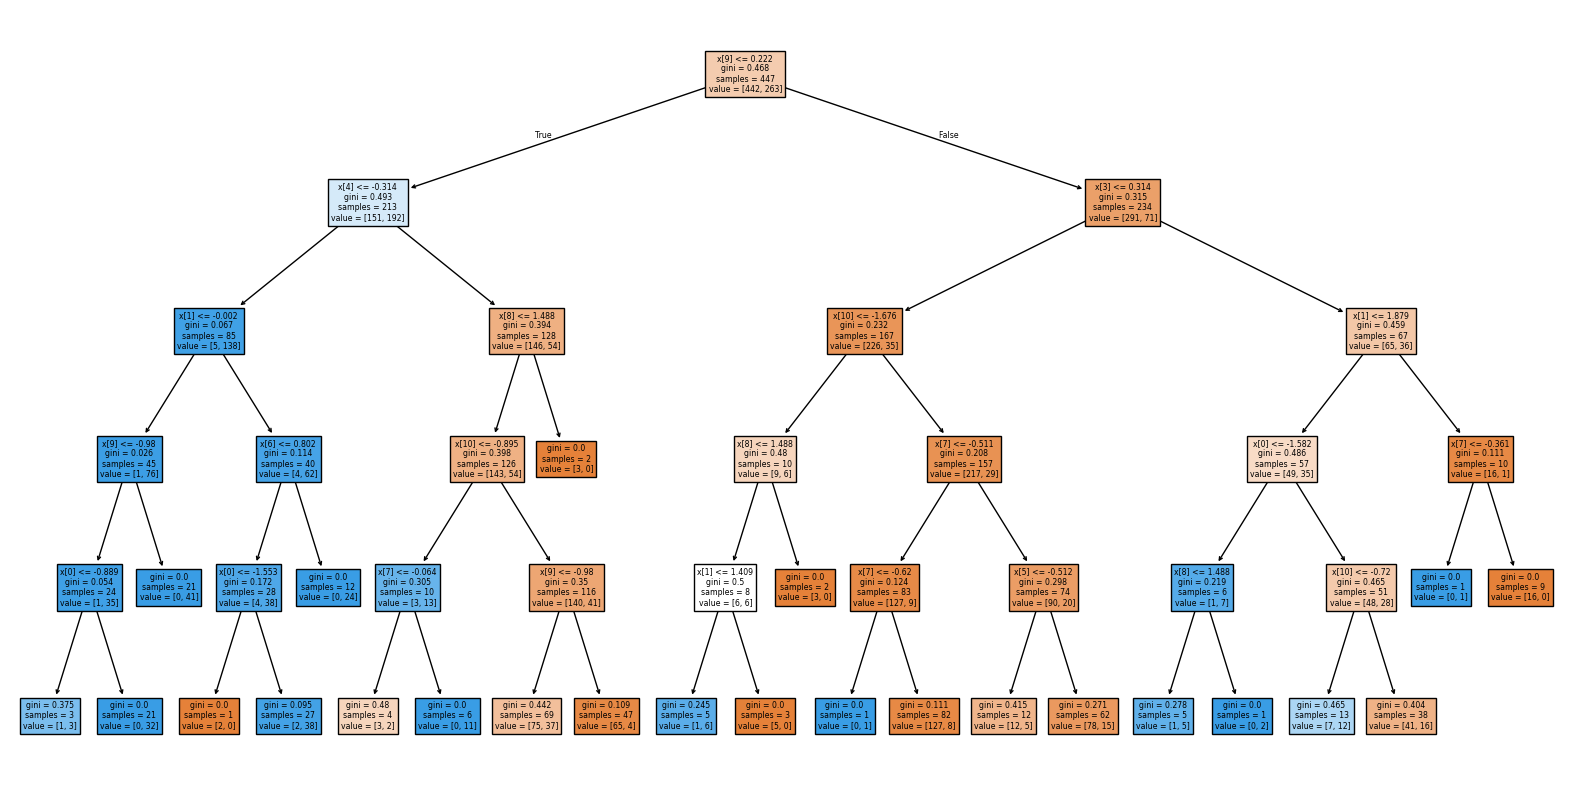

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
print(rf.feature_importances_) #which is the input variable that mostly contributes in prediction

plt.figure(figsize =(20,10))
tree.plot_tree(rf.estimators_[0], filled=True)
plt.show()
